# Experiment 14

## Aim

To investigate the Curse of Dimensionality by generating datasets with different numbers of features and analyzing the effect on Euclidean distance and classification accuracy.

## Theory

The Curse of Dimensionality refers to the problems that arise when the number of features (dimensions) in a dataset becomes very large.

As the number of dimensions increases:

• Distances between points become more similar.
• Data becomes sparse.
• Learning algorithms require more training data.
• Model performance may decrease due to overfitting.

Distance Formula (Euclidean Distance):

d = √[(x₁−y₁)² + (x₂−y₂)² + ... + (xₙ−yₙ)²]

where n is the number of dimensions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist

In [2]:
dimensions = [2,5,10,20,50,100]

avg_distance = []

accuracy = []

In [3]:
for d in dimensions:

    X, y = make_classification(
        n_samples=500,
        n_features=d,
        n_informative=max(2, d//2),
        n_redundant=0,
        random_state=42
    )

    # Average Euclidean Distance
    dist = np.mean(pdist(X))
    avg_distance.append(dist)

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42
    )

    # KNN Classifier
    model = KNeighborsClassifier(n_neighbors=5)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy.append(acc)

print("Experiment Completed Successfully")

Experiment Completed Successfully


In [4]:
print("Dimensions\tAverage Distance\tAccuracy")

for d, dist, acc in zip(dimensions, avg_distance, accuracy):

    print(f"{d}\t\t{dist:.2f}\t\t\t{acc:.3f}")

Dimensions	Average Distance	Accuracy
2		2.38			0.953
5		3.44			0.880
10		5.47			0.913
20		9.85			0.887
50		21.92			0.920
100		42.71			0.900


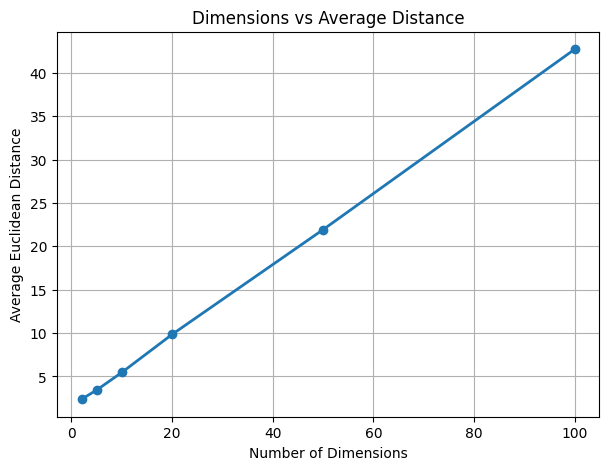

In [5]:
plt.figure(figsize=(7,5))

plt.plot(dimensions,
         avg_distance,
         marker="o",
         linewidth=2)

plt.title("Dimensions vs Average Distance")

plt.xlabel("Number of Dimensions")

plt.ylabel("Average Euclidean Distance")

plt.grid(True)

plt.show()

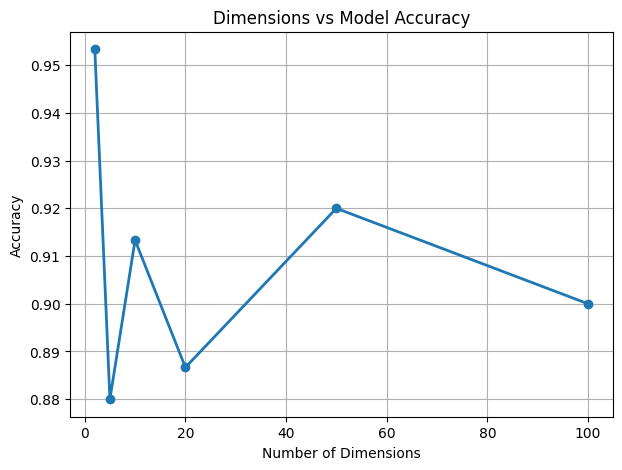

In [6]:
plt.figure(figsize=(7,5))

plt.plot(dimensions,
         accuracy,
         marker="o",
         linewidth=2)

plt.title("Dimensions vs Model Accuracy")

plt.xlabel("Number of Dimensions")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [7]:
print("Analysis")

print("-----------------------")

print("1. Average distance increases with dimensions.")

print("2. Data becomes sparse in high-dimensional space.")

print("3. KNN accuracy gradually decreases.")

print("4. High-dimensional datasets require more samples.")

print("5. Feature selection helps reduce this problem.")

Analysis
-----------------------
1. Average distance increases with dimensions.
2. Data becomes sparse in high-dimensional space.
3. KNN accuracy gradually decreases.
4. High-dimensional datasets require more samples.
5. Feature selection helps reduce this problem.


2-D Space

●      ●

    ●

        ●

Distances are meaningful.


----------------------------


100-D Space

●      ●      ●

●    ●    ●

●  ●   ●

Data becomes sparse

Distances become similar

Learning becomes difficult